In [44]:
import numpy as np
import matplotlib.pyplot as plt

# pytorch stuff
import torch
import torch.nn as nn
from torch.nn import functional as F

from transformers import AutoModelForCausalLM, AutoTokenizer, get_linear_schedule_with_warmup

from torch.optim import AdamW

# for text printing
import textwrap

!pip install torchinfo
from torchinfo import summary

import requests

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#

# Import Tokenizer for GP-Neo from Eleuther AI

In [46]:
# Eleuther's tokenizer
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125m")
tokenizer.pad_token_id = tokenizer.encode(' ')[0]

# Import GPT-Neo model from HuggingFace
- Once for training with text from "Alice in Wonderland"
- Other for training in text from "Edgar Allen Poe"

In [47]:
# Load two GPT-Neo models
modelAlice = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m")
modelEAP = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m")

modelAlice.to(device);
modelEAP.to(device);
#

In [48]:
# Import texts for "Through the Looking Glass" and "Edgar Allen" Poe texts
text = requests.get('https://www.gutenberg.org/cache/epub/11/pg11.txt').text
aliceTokens =torch.tensor(tokenizer.encode(text),dtype=torch.long)

# Import texts for Edgar Allen Poe"
text = requests.get('https://www.gutenberg.org/cache/epub/2148/pg2148.txt').text
eapTokens =torch.tensor(tokenizer.encode(text),dtype=torch.long)

print(f'{'Number of tokens for "Alice in Wonderland"':42}: {len(aliceTokens):>7,}')
print(f'{'Number of tokens for "Edgar Allen Poe"':42}: {len(eapTokens):>7,}')

Token indices sequence length is longer than the specified maximum sequence length for this model (52954 > 2048). Running this sequence through the model will result in indexing errors


Number of tokens for "Alice in Wonderland":  52,954
Number of tokens for "Edgar Allen Poe"    : 197,306


# Train the model

In [49]:
# Function to train the model

def trainLLM(num_steps, seq_len, batch_size, tokens, model, optimizer):
    model.train()
    train_loss = np.zeros(num_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.1 * num_steps)),
        num_training_steps=num_steps
    )

    for step in range(num_steps):
        ix = torch.randint(len(tokens) - seq_len, size=(batch_size,))
        X  = tokens[ix[:, None] + torch.arange(seq_len)].to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(X, labels=X)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        train_loss[step] = loss.item()
        if step % 50 == 0:
            print(f"Step {step:4}/{num_steps}, loss: {loss.item():.4f}")

    return train_loss

In [50]:
# IMPORTANT: start from a fresh base model, not the collapsed one
modelAlice = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m").to(device)

learning_rate = 1e-5
optimizer_alice = torch.optim.AdamW(
    modelAlice.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

alice_loss = trainLLM(
    num_steps=476,
    seq_len=256,
    batch_size=32,
    tokens=aliceTokens,
    model=modelAlice,
    optimizer=optimizer_alice
)

Step    0/476, loss: 2.5836
Step   50/476, loss: 2.3583
Step  100/476, loss: 2.0485
Step  150/476, loss: 1.9359
Step  200/476, loss: 1.8459
Step  250/476, loss: 1.7837
Step  300/476, loss: 1.7204
Step  350/476, loss: 1.6876
Step  400/476, loss: 1.6657
Step  450/476, loss: 1.6652


In [52]:
# IMPORTANT: start from a fresh base model, not the collapsed one
modelEAP = AutoModelForCausalLM.from_pretrained("EleutherAI/gpt-neo-125m").to(device)

learning_rate = 1e-5
optimizer_eap = torch.optim.AdamW(
    modelEAP.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

eap_loss = trainLLM(
    num_steps=476,
    seq_len=256,
    batch_size=32,
    tokens=eapTokens,
    model=modelEAP,
    optimizer=optimizer_eap
)

Step    0/476, loss: 2.6733
Step   50/476, loss: 2.4934
Step  100/476, loss: 2.3237
Step  150/476, loss: 2.3290
Step  200/476, loss: 2.3054
Step  250/476, loss: 2.2192
Step  300/476, loss: 2.2551
Step  350/476, loss: 2.2252
Step  400/476, loss: 2.1946
Step  450/476, loss: 2.2014


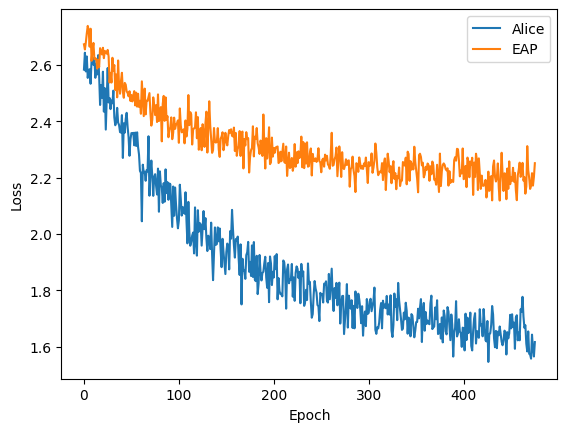

In [53]:
# Plot the losses
plt.plot(alice_loss, label='Alice')
plt.plot(eap_loss, label='EAP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()

# Conversation between two models

In [55]:
# Initial prompt
prompt = "Hello, my name is Alice"
# prompt = " "
alice_response = prompt
promptTokens = tokenizer(prompt,return_tensors='pt').to(device)

print(f' Initial Prompt from Alice: {prompt} \n Length: {len(promptTokens["input_ids"][0])}')

for i in range(5):

  # EAP's response
  outAlice = tokenizer(alice_response, return_tensors='pt').to(device)
  input_token_ids = outAlice["input_ids"]
  attention_mask = outAlice["attention_mask"]
  with torch.no_grad():
    outEAP = modelEAP.generate(
        input_ids=input_token_ids,
        attention_mask=attention_mask,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    ).cpu()
    eap_response = tokenizer.decode(outEAP[0][input_token_ids.shape[1]:], skip_special_tokens=True)

  print(f'\n ** Loop: {i+1} Edgar model responds: \n{'\n'.join(textwrap.wrap(eap_response, 50))} \n Length: {outEAP.shape[1]}')

  # Alice's response
  outEAP = tokenizer(eap_response, return_tensors='pt').to(device)
  input_token_ids = outEAP["input_ids"]
  attention_mask = outEAP["attention_mask"]
  with torch.no_grad():
    outAlice = modelAlice.generate(
          input_ids=input_token_ids,
          attention_mask=attention_mask,
          max_new_tokens=50,
          do_sample=True,
          temperature=0.8,
          top_p=0.9,
          repetition_penalty=1.15,
          no_repeat_ngram_size=3,
          eos_token_id=tokenizer.eos_token_id,
          pad_token_id=tokenizer.eos_token_id,
      ).cpu()
    alice_response = tokenizer.decode(outAlice[0][input_token_ids.shape[1]:], skip_special_tokens=True)

  print(f'\n ** Loop: {i+1} Alice model responds: \n{'\n'.join(textwrap.wrap(alice_response, 50))} \n Length: {outAlice.shape[1]}')

 Initial Prompt from Alice: Hello, my name is Alice 
 Length: 6

 ** Loop: 1 Edgar model responds: 
 Coddington.        I am a member of the Board of
Directors of the American Gas  _Lubricating and
Rubber Co., Ltd._  EXECUTIVE SUMMARY  The United
States 
 Length: 56

 ** Loop: 1 Alice model responds: 
 Government owns and has the right to  comply with
the provisions of this Act by performing  any of
the following:  1.  Completed or modified work
under the authority  of the President, by the
United States, under 
 Length: 100

 ** Loop: 2 Edgar model responds: 
 his direction,  and with the permission of the
Congress.  2. The President shall have power to
enter into any agreement  with any person, firm,
or corporation, or any officer of  which the
United Kingdom or any 
 Length: 100

 ** Loop: 2 Alice model responds: 
 person in the United States,         “‘Such an
agreement, as may be found in the laws of the
United States, shall govern all business of the
United  States, and shall giv